In [1]:
import MCtools
from getdist import plots, MCSamples
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/ACT_DR6/chains"
clth = hp.read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = np.arange(len(clth[0]))
maps = ['dr6_pa4_f220','dr6_pa5_f090','dr6_pa5_f150','dr6_pa6_f090','dr6_pa6_f150']

In [2]:
ACT25 = {'cosmomc_theta':0.0104056,'ombh2':0.02259,'omch2':0.1238,'logA':3.053,'ns':0.9666,'tau':0.0562,
        'a_tSZ':3.35,'a_kSZ':1.48,'a_p':7.65,'beta_p':1.87,'beta_c':1.87,'a_c':3.69,'a_s':2.86,'a_gtt':7.97,'xi':0.088,
        'beta_s':-2.783,'a_gte':0.419,'a_gee':0.167,'a_pste':-0.025,'a_psee':0.,
        **{'cal_'+m:v for m,v in zip(maps,[0.9807,1.0003,0.9992,0.99996,1.0015])},
        **{'calE_'+m:v for m,v in zip(maps[1:],[0.9877,0.9976,0.9978,0.9969])},
        'calG_all':1.0002,
        **{'bandint_shift_'+m:v for m,v in zip(maps,[6.5,-0.05,-0.998,0.56,-0.35])}}
MCtools.parname.update({'ACT_cib_ps':r'$A_\mathrm{IR}^{ACT}$',
                        'ACT_radio_TT':r'$A_\mathrm{radioTT}^{ACT}$',
                        'ACT_radio_TE':r'$A_\mathrm{radioTE}^{ACT}$',
                        'ACT_radio_EE':r'$A_\mathrm{radioEE}^{ACT}$',
                        'ACT_AdustTT':r'$A_\mathrm{dust}^\mathrm{TT}$',
                        'ACT_AdustTE':r'$A_\mathrm{dust}^\mathrm{TE}$',
                        'ACT_AdustEE':r'$A_\mathrm{dust}^\mathrm{EE}$'})

In [15]:
#runnames = ['hillik_act_dr6','hillik_act_dr6_Tcib25','hillik_act_dr6_nobp','hillik_act_dr6_nopsE','mflike_act_dr6','mflike_act_dr6_noalphasz']
runnames = ['hillik_act_TTTEEE','hillik_act_dr6_nopsE','mflike_act_dr6_nopsE']
#runnames = ['hillik_act_dr6_Tcib25','hillik_act_dr6_nopsE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9) for run in runnames]

hillik_act_TTTEEE: 137699  137816  139260  136961 
hillik_act_dr6_nopsE: 92161  95791  98039  97246 
mflike_act_dr6_nopsE: 121361  124396  121426  123761 


In [16]:
listpar = ['ombh2','omch2','theta_s_100','tau','ns','logA']
support = {'ombh2':(0.017,0.027),'omch2':(0.09,0.15),'theta_s_100':(1.03,1.05),'tau':(0.01,0.15),'ns':(0.9,1.1),'logA':(2.6,3.5)}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames,legend_loc='upper right', markers=ACT25)

KeyError: 'ombh2'

Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

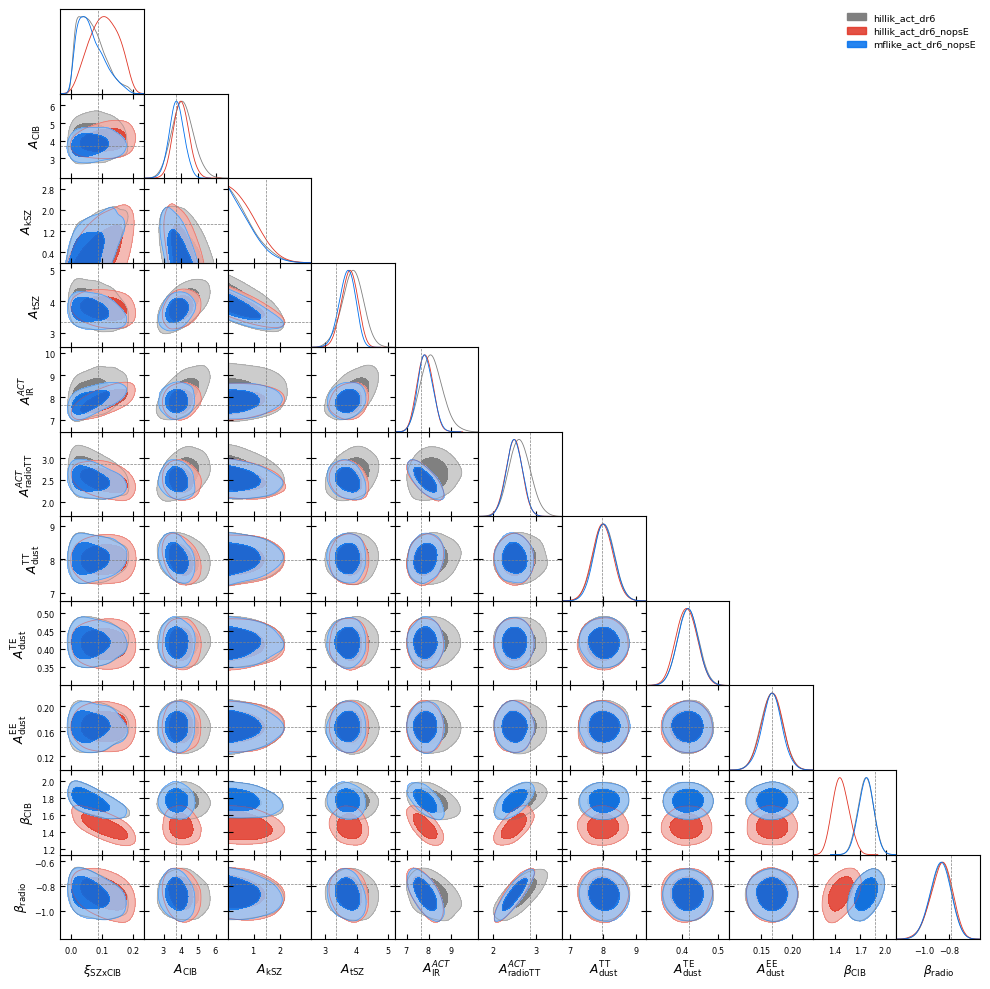

In [5]:
pars = {'xi':'xi','a_c':'Acib','a_kSZ':'Aksz','a_tSZ':'Atsz',
        'a_p':'ACT_cib_ps','a_s':'ACT_radio_TT',#'a_pste':'ACT_radio_TE','a_psee':'ACT_radio_EE',
        'a_gtt':'ACT_AdustTT','a_gte':'ACT_AdustTE','a_gee':'ACT_AdustEE',
        'beta_c':'beta_cib','beta_s':'beta_radio'}#,'beta_p':'beta_dusty'
for chain in chains+[ACT25]:
    for k,v in pars.items(): 
        if k in chain: chain[v] = chain[k]
    if 'beta_s' in chain: chain['beta_radio'] = chain['beta_s']+2
    if 'ACT_radio_ps' in chain: chain['ACT_radio_TT'] = chain['ACT_radio_ps']
listpar = list(pars.values())
support = {'xi':[-0.3,0.4],'ACT_radio_EE':[0,1],'Aksz':[0,5]}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar if p in chain], names=[p for p in listpar if p in chain], labels=[l for l,p in zip(labels,listpar) if p in chain], ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames,legend_loc='upper right', markers=ACT25)

Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

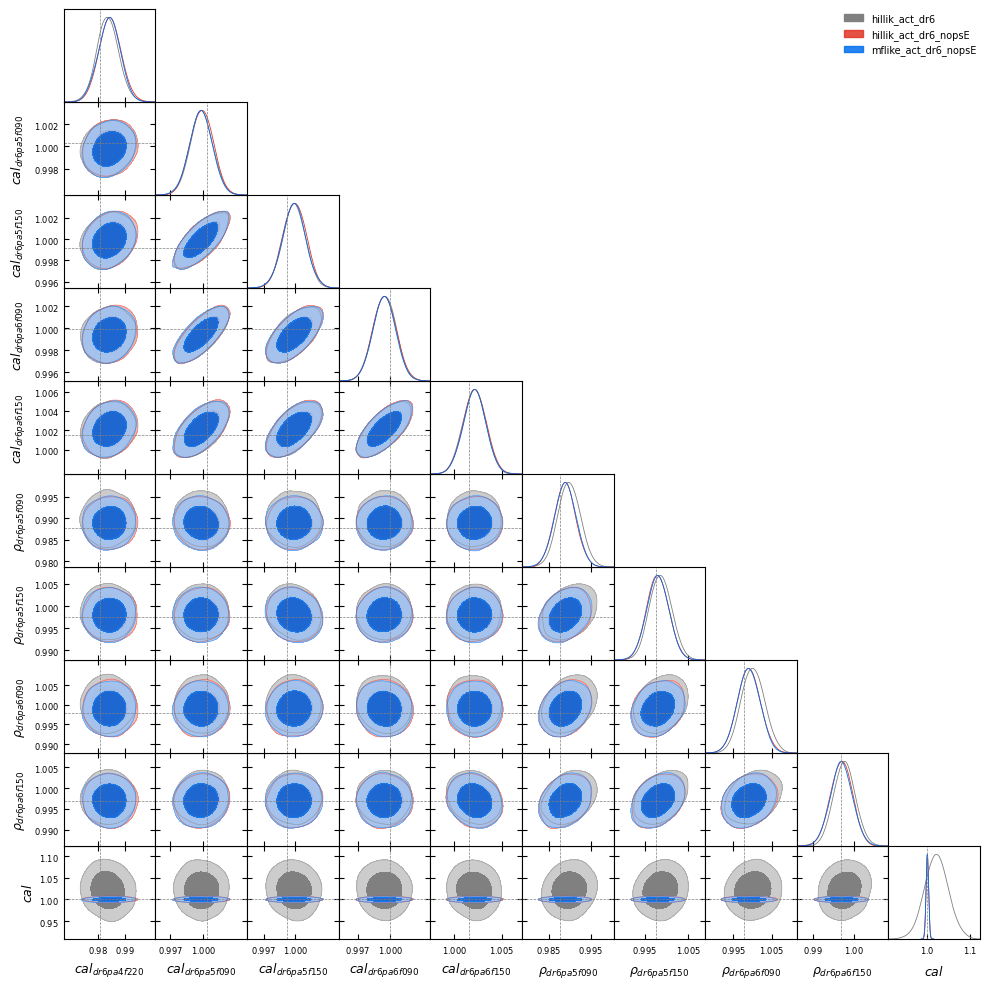

In [6]:
calpars = {**{'cal_'+m:'ACT_cal_'+m for m in maps},**{'calE_'+m:'ACT_pe_'+m for m in maps[1:]},'calG_all':'ACT_cal'}
for chain in chains+[ACT25]:
    for k,v in calpars.items(): 
        if k in chain: chain[v] = chain[k]
listpar = list(calpars.values())
labels = [p.replace('_','').replace('ACTcal','cal_{').replace('ACTpe','\\rho_{')+'}' for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames, legend_loc='upper right', markers=ACT25)

Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

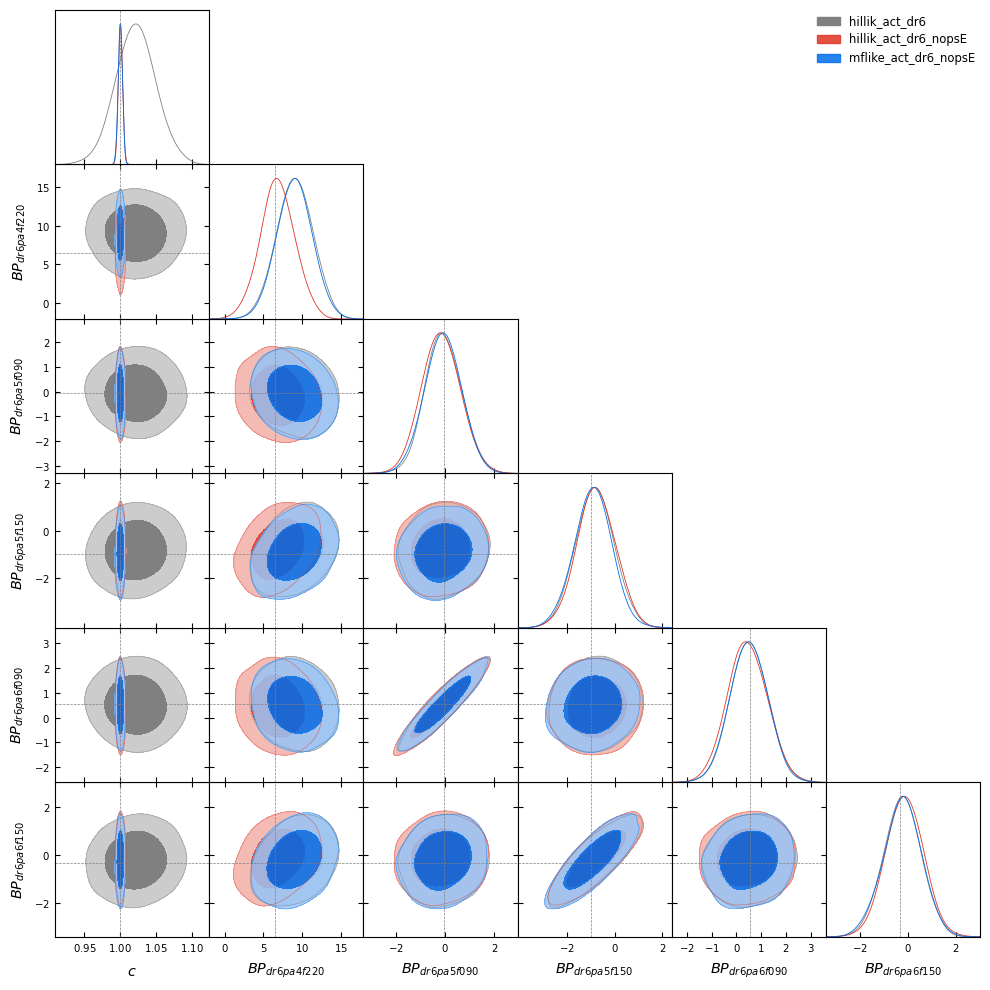

In [7]:
bppars = {**{'bandint_shift_'+m:'ACT_band_shift_'+m for m in maps}}
for chain in chains+[ACT25]:
    for k,v in bppars.items(): 
        if k in chain: chain[v] = chain[k]
listpar = ['ACT_cal']+list(bppars.values())
labels = [p.replace('_','').replace('ACTbandshift','BP_{').replace('ACTcal','c_{')+'}' for p in listpar]
samples = [MCSamples( samples=[chain[p] for p in listpar if p in chain], names=[p for p in listpar if p in chain], labels=[l for l,p in zip(labels,listpar) if p in chain], ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled=True, legend_labels=runnames, legend_loc='upper right', markers=ACT25)

In [14]:
#for par in chains[0].keys():
#    MCtools.PrintMean( chains, par)
MCtools.PrintMean( chains, list(chains[0].keys()), label=runnames)

                                      hillik_act_dr6      hillik_act_dr6_nopsE   mflike_act_dr6_nopsE 
minuslogpost                    =  2940.39954 +/- 3.47192 |  2932.93274 +/- 4.01825 |  2937.78866 +/- 3.92020
H0                              =  66.73466 +/- 1.10282 |  65.83972 +/- 0.71992 |  65.81597 +/- 0.76502
logA                            =  3.09084 +/- 0.04929 |  3.05545 +/- 0.01494 |  3.05493 +/- 0.01259
ns                              =  0.97510 +/- 0.00919 |  0.97263 +/- 0.00808 |  0.97282 +/- 0.00677
ombh2                           =  0.02263 +/- 0.00014 |  0.02257 +/- 0.00014 |  0.02257 +/- 0.00015
omch2                           =  0.12227 +/- 0.00363 |  0.12461 +/- 0.00227 |  0.12465 +/- 0.00183
tau                             =  0.05604 +/- 0.00613 |  0.05704 +/- 0.00616 |  0.05713 +/- 0.00570
Atsz                            =  3.87240 +/- 0.36199 |  3.77363 +/- 0.28877 |  3.70324 +/- 0.26826
Aksz                            =  0.68971 +/- 0.54715 |  0.74866 +/- 0.54397